# Inspect Loss Trigger Analysis JSON + Full Logits NPZ

Loads and explores:
- JSON metadata/events report
- Optional full-logits NPZ artifact for full-vocab histograms


In [1]:
import io
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from etils import epath
from IPython.display import display, Markdown


In [2]:
REPORT_PATH = "gs://demand-v4-checkpoint-storage/glowing-moon-136/evaluation_metrics/step_1050/loss_trigger_analysis_step_1050_valid.json"
FULL_LOGITS_PATH = "gs://demand-v4-checkpoint-storage/glowing-moon-136/evaluation_metrics/step_1050/loss_trigger_full_logits_step_1050_valid.npz"

with epath.Path(REPORT_PATH).open('r') as f:
    report = json.load(f)

print(f"Loaded JSON: {REPORT_PATH}")
print(f"run={report.get('run_name')} step={report.get('checkpoint_step')} split={report.get('split')}")
print("analysis config:", report.get('analysis', {}))


Loaded JSON: gs://demand-v4-checkpoint-storage/glowing-moon-136/evaluation_metrics/step_1050/loss_trigger_analysis_step_1050_valid.json
run=glowing-moon-136 step=1050 split=valid
analysis config: {'top_batches': 20, 'top_token_events': 50, 'context_window': 40, 'top_logits_k': 10, 'tokenizer_name': 'gpt2', 'save_full_logits': True, 'full_logits_dtype': 'float32', 'swap_relative_positions': [0], 'swap_replacement_token_ids': [50256]}


In [3]:
full_logits = None
try:
    with epath.Path(FULL_LOGITS_PATH).open('rb') as f:
        raw = f.read()
    full_logits = np.load(io.BytesIO(raw))
    print(f"Loaded NPZ: {FULL_LOGITS_PATH}")
    print("keys:", list(full_logits.keys()))
except Exception as e:
    print("Full-logits NPZ not available or failed to load:", e)
    print("Continuing with JSON-only analysis.")


Loaded NPZ: gs://demand-v4-checkpoint-storage/glowing-moon-136/evaluation_metrics/step_1050/loss_trigger_full_logits_step_1050_valid.npz
keys: ['before_logits', 'before_rank', 'before_batch_index', 'before_example_index', 'before_position', 'after_logits', 'after_rank', 'after_batch_index', 'after_example_index', 'after_position']


In [4]:
df_batches = pd.DataFrame(report.get('top_batches_by_mean_loss', []))
df_events = pd.DataFrame(report.get('top_token_events', []))

print('Top-batch rows:', len(df_batches))
print('Top-event rows:', len(df_events))

display(df_batches.head(20))
if len(df_events):
    cols = ['rank','loss','recomputed_loss','batch_index','example_index','position','input_token_id','target_token_id']
    display(df_events[cols].head(20))


Top-batch rows: 20
Top-event rows: 50


,rank,batch_index,mean_loss,max_token_loss
0,1,35,42.371979,144.950500
1,2,37,42.234943,146.976944
2,3,15,42.216976,141.970413
3,4,61,42.175179,164.202133
4,5,18,42.173325,146.134979
5,6,66,42.169540,162.000046
6,7,65,42.168995,141.571884
7,8,46,42.163445,149.850693
8,9,0,42.158264,144.613052
9,10,69,42.150188,152.335632


,rank,loss,recomputed_loss,batch_index,example_index,position,input_token_id,target_token_id
0,1,610.000000,607.692749,31,116,14,9455,1924
1,2,570.000000,570.023804,41,34,3,1936,19422
2,3,268.974060,269.435547,75,237,1,8722,44105
3,4,198.000000,198.041290,58,24,1,286,10397
4,5,193.002991,193.393768,41,81,4,286,12972
5,6,189.000000,189.069336,72,152,1,1010,10695
6,7,182.500305,182.388672,9,247,3,2855,19479
7,8,176.693314,176.529343,27,23,686,466,49620
8,9,176.126923,176.080887,58,203,0,1239,11855
9,10,175.506653,175.256912,53,17,932,318,4068


In [5]:
if len(df_events):
    display(df_events[['loss','recomputed_loss']].describe())
    max_abs_diff = (df_events['loss'] - df_events['recomputed_loss']).abs().max()
    print('max |loss - recomputed_loss| =', float(max_abs_diff))

    display(Markdown('### Top 10 Highest-Loss Token Events'))
    show_cols = ['rank','loss','batch_index','example_index','position','input_token','target_token','context_text']
    display(df_events.sort_values('loss', ascending=False).head(10)[show_cols])


,loss,recomputed_loss
count,50.000000,50.000000
mean,180.958958,180.894488
std,86.489403,86.280603
min,150.638718,150.373367
25%,153.750271,153.422535
50%,158.604958,158.747749
75%,166.625607,166.721680
max,610.000000,607.692749


max |loss - recomputed_loss| = 2.3072509765625


### Top 10 Highest-Loss Token Events

,rank,loss,batch_index,example_index,position,input_token,target_token,context_text
0,1,610.000000,31,116,14,Command,ery,the commencement of the 50 th Commemoration o...
1,2,570.000000,41,34,3,five,pickup,only need regarding five
2,3,268.974060,75,237,1,difficulty,siph,some difficulty
3,4,198.000000,58,24,1,of,Samsung,job of
4,5,193.002991,41,81,4,of,py,half-lives of
5,6,189.000000,72,152,1,ters,hire,cesters
6,7,182.500305,9,247,3,bill,banning,and pass a bill
7,8,176.693314,27,23,686,do,tagging,", or any other thing, you’ll be covered.\nAn ..."
8,9,176.126923,58,203,0,never,defect,never
9,10,175.506653,53,17,932,is,Iran,are used to spread more terror in Israel. Rep...


In [13]:
def show_event(rank: int):
    rows = [r for r in report.get('top_token_events', []) if r.get('rank') == rank]
    if not rows:
        print(f'No event with rank={rank}')
        return
    r = rows[0]
    print(f"rank={r['rank']} loss={r['loss']:.6f} batch={r['batch_index']} ex={r['example_index']} pos={r['position']}")
    print(f"input_token_id={r['input_token_id']} input_token={r.get('input_token')!r}")
    print(f"target_token_id={r['target_token_id']} target_token={r.get('target_token')!r}")
    print('context_text:')
    print(r.get('context_text'))

    print('\nTop logits (before):')
    for i, t in enumerate(r.get('top_logits', []), start=1):
        print(f"  {i:2d}. id={t['token_id']:<6} logit={t['logit']:.4f} token={t.get('token')!r}")

    if 'swap_analysis' in r:
        s = r['swap_analysis']
        print('\nSwap analysis present')
        print('loss_after_swap:', s.get('loss_after_swap'))
        print('loss_delta:', s.get('loss_delta'))
        print('target_logit_delta:', s.get('target_logit_delta'))

        print('\nTop logits (after swap):')
        for i, t in enumerate(s.get('top_logits_after_swap', []), start=1):
            print(f"  {i:2d}. id={t['token_id']:<6} logit={t['logit']:.4f} token={t.get('token')!r}")

show_event(1)


rank=1 loss=610.000000 batch=31 ex=116 pos=14
input_token_id=9455 input_token=' Command'
target_token_id=1924 target_token='ery'
context_text:
 the commencement of the 50 th Commemoration of that War. The Command

Top logits (before):
   1. id=856    logit=782.0470 token='ible'
   2. id=902    logit=669.8608 token='ments'
   3. id=1522   logit=640.6749 token='ured'
   4. id=425    logit=603.5615 token='ive'
   5. id=25085  logit=595.2563 token='ivism'
   6. id=1473   logit=586.9561 token='ently'
   7. id=341    logit=573.6346 token='ation'
   8. id=3263   logit=541.4479 token='ament'
   9. id=25253  logit=530.9208 token='itious'
  10. id=30944  logit=525.2563 token='ivist'

Swap analysis present
loss_after_swap: 10.869379043579102
loss_delta: -596.8233699798584
target_logit_delta: -87.6485595703125

Top logits (after swap):
   1. id=12     logit=95.2937 token='-'
   2. id=464    logit=94.1788 token='The'
   3. id=32     logit=94.0546 token='A'
   4. id=50     logit=93.9743 token='S'
  

In [ ]:
QUERY = ' the'

def contains_q(x):
    if x is None:
        return False
    return QUERY.lower() in str(x).lower()

filtered = [
    r for r in report.get('top_token_events', [])
    if contains_q(r.get('context_text')) or contains_q(r.get('target_token'))
]

print(f"query={QUERY!r}, matched={len(filtered)}")
if filtered:
    display(pd.DataFrame(filtered)[['rank','loss','target_token','context_text']].head(30))


In [7]:
FIG_DIR = Path('loss_trigger_analysis_figures') / f"step_{report.get('checkpoint_step')}"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Saving figures to', FIG_DIR.resolve())


Saving figures to /home/tingchen/loss-spikes-project/picodo/loss_trigger_analysis_figures/step_1050


before_logits shape: (50, 50260)
after_logits shape: (50, 50260)


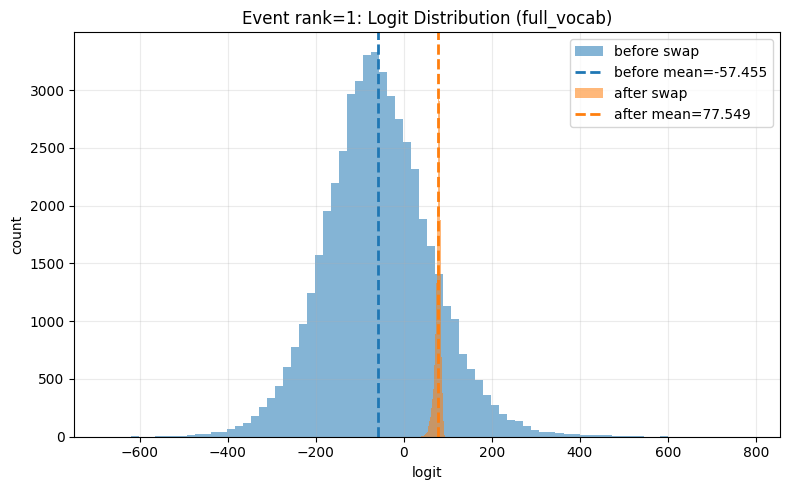

Saved loss_trigger_analysis_figures/step_1050/event_rank_1_logits_hist_before_after_full_vocab.png


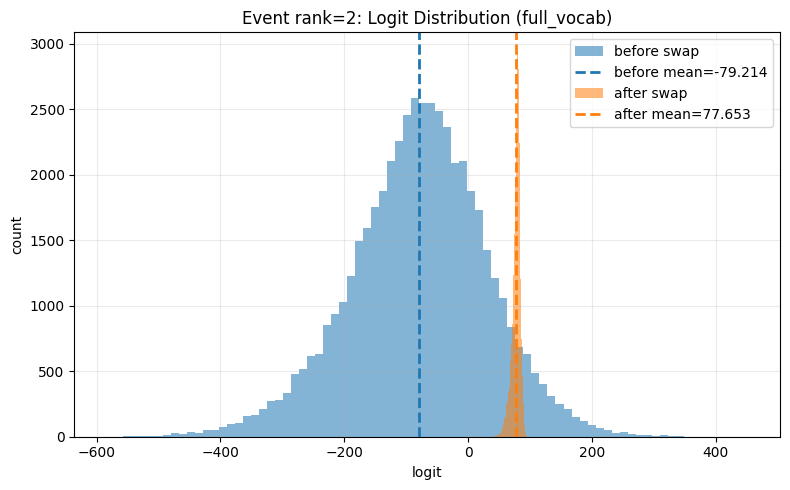

Saved loss_trigger_analysis_figures/step_1050/event_rank_2_logits_hist_before_after_full_vocab.png


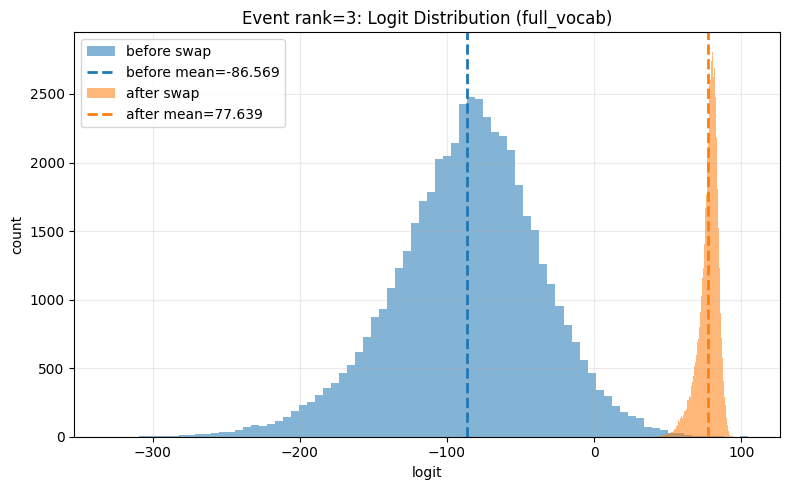

Saved loss_trigger_analysis_figures/step_1050/event_rank_3_logits_hist_before_after_full_vocab.png


In [14]:
# Per-event histograms for top-3 events (separate plots per rank).
# Uses full-vocab NPZ logits when available; falls back to JSON top-k.

TOP_RANKS = [1, 2, 3]


def _plot_event_hist(rank, before_vals, after_vals, suffix):
    fig, ax = plt.subplots(figsize=(8, 5))
    if len(before_vals):
        ax.hist(before_vals, bins=80, alpha=0.55, label='before swap', color='tab:blue')
        before_mean = float(np.mean(before_vals))
        ax.axvline(before_mean, color='tab:blue', linestyle='--', linewidth=2, label=f'before mean={before_mean:.3f}')
    if len(after_vals):
        ax.hist(after_vals, bins=80, alpha=0.55, label='after swap', color='tab:orange')
        after_mean = float(np.mean(after_vals))
        ax.axvline(after_mean, color='tab:orange', linestyle='--', linewidth=2, label=f'after mean={after_mean:.3f}')
    ax.set_title(f'Event rank={rank}: Logit Distribution ({suffix})')
    ax.set_xlabel('logit')
    ax.set_ylabel('count')
    ax.grid(alpha=0.25)
    ax.legend()
    out = FIG_DIR / f'event_rank_{rank}_logits_hist_before_after_{suffix}.png'
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    plt.show()
    print('Saved', out)


if full_logits is not None:
    before_logits = full_logits['before_logits']
    after_logits = full_logits['after_logits']
    before_rank = full_logits['before_rank']
    after_rank = full_logits['after_rank']

    print('before_logits shape:', before_logits.shape)
    print('after_logits shape:', after_logits.shape)

    for rank in TOP_RANKS:
        before_idx = np.where(before_rank == rank)[0]
        after_idx = np.where(after_rank == rank)[0]

        before_vals = before_logits[before_idx].reshape(-1) if len(before_idx) else np.array([])
        after_vals = after_logits[after_idx].reshape(-1) if len(after_idx) else np.array([])

        if len(before_vals) == 0 and len(after_vals) == 0:
            print(f'No data for rank={rank} in NPZ.')
            continue

        _plot_event_hist(rank, before_vals, after_vals, suffix='full_vocab')
else:
    print('NPZ missing: using JSON top-k logits fallback.')
    rank_to_vals = {r: {'before': [], 'after': []} for r in TOP_RANKS}

    for r in report.get('top_token_events', []):
        rank = r.get('rank')
        if rank not in rank_to_vals:
            continue
        rank_to_vals[rank]['before'].extend(
            [float(x['logit']) for x in (r.get('top_logits') or []) if 'logit' in x]
        )
        swap = r.get('swap_analysis', {})
        rank_to_vals[rank]['after'].extend(
            [float(x['logit']) for x in (swap.get('top_logits_after_swap') or []) if 'logit' in x]
        )

    for rank in TOP_RANKS:
        before_vals = np.asarray(rank_to_vals[rank]['before'])
        after_vals = np.asarray(rank_to_vals[rank]['after'])
        if len(before_vals) == 0 and len(after_vals) == 0:
            print(f'No data for rank={rank} in JSON fallback.')
            continue
        _plot_event_hist(rank, before_vals, after_vals, suffix='topk_fallback')


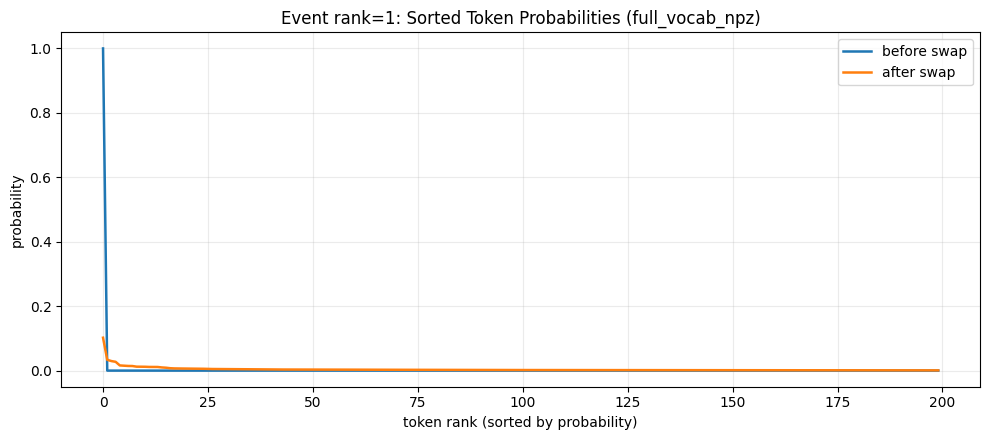

Saved loss_trigger_analysis_figures/step_1050/event_rank_1_overlay_sorted_token_probs_full_vocab_npz.png
rank=1 before: max_p=1.000000e+00, p99=9.931299e-230, entropy=0.000000
  top token IDs before: [856, 902, 1522, 425, 25085, 1473, 341, 3263, 25253, 30944]
  top probs before    : [1.0, 1.897452752568963e-49, 4.007651677244559e-62, 3.0531187852911677e-78, 7.547883375142954e-82, 1.8753410227442854e-85, 3.0737242798432966e-91, 3.2294558986831872e-105, 8.655548508514891e-110, 3.000623097038132e-112]
rank=1 after : max_p=1.021430e-01, p99=2.485757e-04, entropy=5.846130
  top token IDs after : [12, 464, 32, 50, 14398, 35, 1212, 1135, 34, 40]
  top probs after     : [0.10214302263140948, 0.03349995168915428, 0.029586618900839263, 0.02730309127596664, 0.016053108666748254, 0.01512347664839619, 0.014460017710745857, 0.014227366792394225, 0.012236156961364845, 0.012113177815849405]
--------------------------------------------------------------------------------


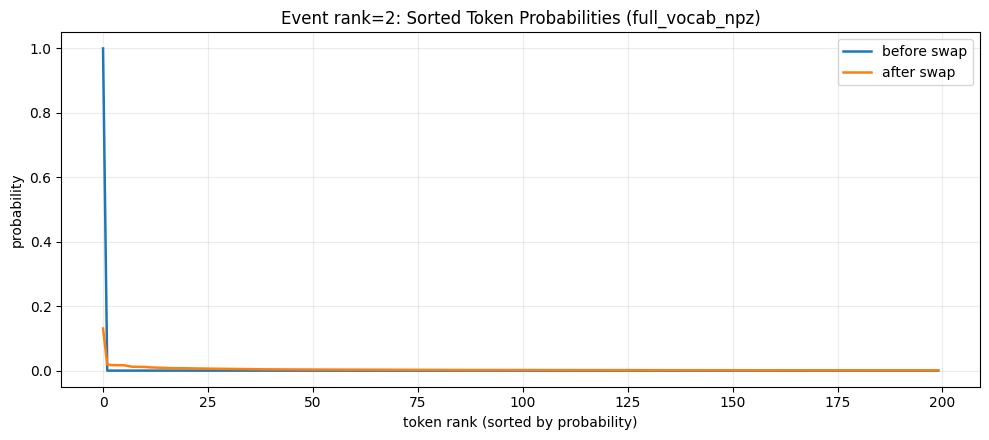

Saved loss_trigger_analysis_figures/step_1050/event_rank_2_overlay_sorted_token_probs_full_vocab_npz.png
rank=2 before: max_p=1.000000e+00, p99=4.093534e-120, entropy=0.000000
  top token IDs before: [28740, 2431, 16746, 2470, 28096, 45133, 28205, 12785, 14653, 10601]
  top probs before    : [1.0, 2.2936174748940035e-25, 2.7430524810960353e-30, 6.36029015305884e-39, 5.033807202137986e-45, 5.344758848055064e-46, 7.4584018914116985e-47, 9.722769539747646e-54, 1.5942966833877373e-56, 4.235322869532966e-58]
rank=2 after : max_p=1.307189e-01, p99=2.499703e-04, entropy=5.835071
  top token IDs after : [12, 464, 18234, 25381, 50, 32, 1135, 35, 1212, 6849]
  top probs after     : [0.13071888590976205, 0.01890035490912956, 0.017017304685117546, 0.01695471135785874, 0.016843702410055426, 0.016555386595297938, 0.014354736998271176, 0.011989989071510408, 0.01186233218368776, 0.01147615843242589]
--------------------------------------------------------------------------------


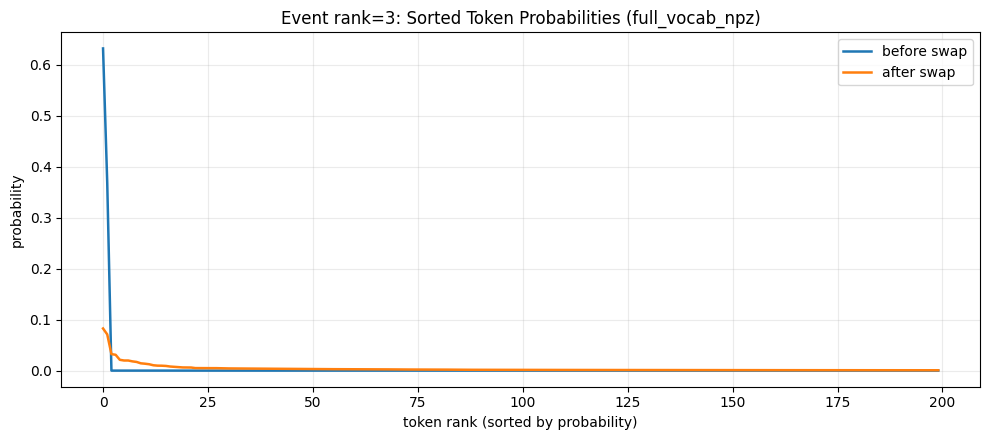

Saved loss_trigger_analysis_figures/step_1050/event_rank_3_overlay_sorted_token_probs_full_vocab_npz.png
rank=3 before: max_p=6.316653e-01, p99=1.435770e-35, entropy=0.658064
  top token IDs before: [28740, 48795, 259, 32416, 9449, 16274, 1548, 20212, 803, 11203]
  top probs before    : [0.6316652830961634, 0.3683346731232024, 3.934958029130115e-08, 3.509568590610461e-09, 8.570894462674426e-10, 4.168252167029173e-11, 2.0300494611186013e-11, 1.670095254511442e-12, 6.237310434878404e-13, 3.7870599260955086e-14]
rank=3 after : max_p=8.261059e-02, p99=2.233984e-04, entropy=5.759287
  top token IDs after : [12, 18234, 6, 1135, 50, 1212, 32, 464, 14618, 1525]
  top probs after     : [0.08261059422292424, 0.07095771233265061, 0.03232511475300557, 0.031042912971413456, 0.02117088102999055, 0.01982366803471416, 0.019821248301054094, 0.018111039322732562, 0.01698884268492276, 0.014311498222309642]
--------------------------------------------------------------------------------


In [18]:
# Sorted token-probability plots for top-3 events with OVERLAID before/after curves.
# x-axis: token rank sorted by probability (descending)
# y-axis: probability
# Uses full-vocab NPZ when available; JSON fallback only supports top-k entries.

TOP_RANKS = [1, 2, 3]
TOP_N = 200  # set to None to plot all tokens (can be very dense)


def softmax_np(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)


def entropy_np(p, eps=1e-40):
    p = np.clip(np.asarray(p, dtype=np.float64), eps, 1.0)
    return float(-np.sum(p * np.log(p)))


def get_event_logits_by_rank(rank):
    if full_logits is not None:
        before_idx = np.where(full_logits['before_rank'] == rank)[0]
        after_idx = np.where(full_logits['after_rank'] == rank)[0]
        before_vec = full_logits['before_logits'][before_idx[0]] if len(before_idx) else None
        after_vec = full_logits['after_logits'][after_idx[0]] if len(after_idx) else None
        return before_vec, after_vec, 'full_vocab_npz'

    rows = [r for r in report.get('top_token_events', []) if r.get('rank') == rank]
    if not rows:
        return None, None, 'json_topk_fallback'
    r = rows[0]
    before_vals = [float(x['logit']) for x in (r.get('top_logits') or []) if 'logit' in x]
    after_vals = [
        float(x['logit'])
        for x in ((r.get('swap_analysis') or {}).get('top_logits_after_swap') or [])
        if 'logit' in x
    ]
    before_vec = np.asarray(before_vals) if before_vals else None
    after_vec = np.asarray(after_vals) if after_vals else None
    return before_vec, after_vec, 'json_topk_fallback'


def _sorted_values(probs):
    if probs is None:
        return None
    order = np.argsort(probs)[::-1]
    if TOP_N is None:
        shown = order
    else:
        shown = order[:TOP_N]
    return shown, probs[shown]


for rank in TOP_RANKS:
    before_logits_vec, after_logits_vec, mode = get_event_logits_by_rank(rank)
    if before_logits_vec is None and after_logits_vec is None:
        print(f'No logits data for rank={rank}.')
        continue

    before_p = softmax_np(before_logits_vec) if before_logits_vec is not None else None
    after_p = softmax_np(after_logits_vec) if after_logits_vec is not None else None

    before_info = _sorted_values(before_p)
    after_info = _sorted_values(after_p)

    if before_info is None and after_info is None:
        print(f'No probability data for rank={rank}.')
        continue

    fig, ax = plt.subplots(figsize=(10, 4.5))
    if before_info is not None:
        _, before_y = before_info
        x_before = np.arange(len(before_y))
        ax.plot(x_before, before_y, color='tab:blue', linewidth=1.8, label='before swap')
    if after_info is not None:
        _, after_y = after_info
        x_after = np.arange(len(after_y))
        ax.plot(x_after, after_y, color='tab:orange', linewidth=1.8, label='after swap')

    ax.set_title(f'Event rank={rank}: Sorted Token Probabilities ({mode})')
    ax.set_xlabel('token rank (sorted by probability)')
    ax.set_ylabel('probability')
    ax.grid(alpha=0.25)
    ax.legend()

    out = FIG_DIR / f'event_rank_{rank}_overlay_sorted_token_probs_{mode}.png'
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    plt.show()
    print('Saved', out)

    if before_p is not None:
        print(
            f"rank={rank} before: max_p={before_p.max():.6e}, "
            f"p99={np.quantile(before_p, 0.99):.6e}, entropy={entropy_np(before_p):.6f}"
        )
        if before_info is not None:
            shown_ids, shown_probs = before_info
            print('  top token IDs before:', shown_ids[:10].tolist())
            print('  top probs before    :', [float(x) for x in shown_probs[:10]])

    if after_p is not None:
        print(
            f"rank={rank} after : max_p={after_p.max():.6e}, "
            f"p99={np.quantile(after_p, 0.99):.6e}, entropy={entropy_np(after_p):.6f}"
        )
        if after_info is not None:
            shown_ids, shown_probs = after_info
            print('  top token IDs after :', shown_ids[:10].tolist())
            print('  top probs after     :', [float(x) for x in shown_probs[:10]])

    print('-' * 80)


In [ ]:
LOCAL_JSON = f"loss_trigger_analysis_step_{report.get('checkpoint_step')}_{report.get('split')}.json"
with open(LOCAL_JSON, 'w') as f:
    json.dump(report, f, indent=2)
print('Saved local JSON copy:', LOCAL_JSON)

if full_logits is not None:
    LOCAL_NPZ = f"loss_trigger_full_logits_step_{report.get('checkpoint_step')}_{report.get('split')}.npz"
    with open(LOCAL_NPZ, 'wb') as f:
        f.write(epath.Path(FULL_LOGITS_PATH).read_bytes())
    print('Saved local NPZ copy:', LOCAL_NPZ)
